<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

# תרגול 10 - 

<span dir="ltr">Tensors, Loss, Gradient Descent, Normalization, Autograd, Optimizer, Training Loop</span>.



</div>

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

## 0. תמונת־על: איך מודל לומד?

בכל <span dir="ltr">Epoch</span> המודל מקבל נתונים, מחשב תחזית, מחשב <span dir="ltr">Loss</span>, מחשב גרדיאנטים, מעדכן פרמטרים וחוזר על התהליך.

</div>

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

<div style="text-align:center;">

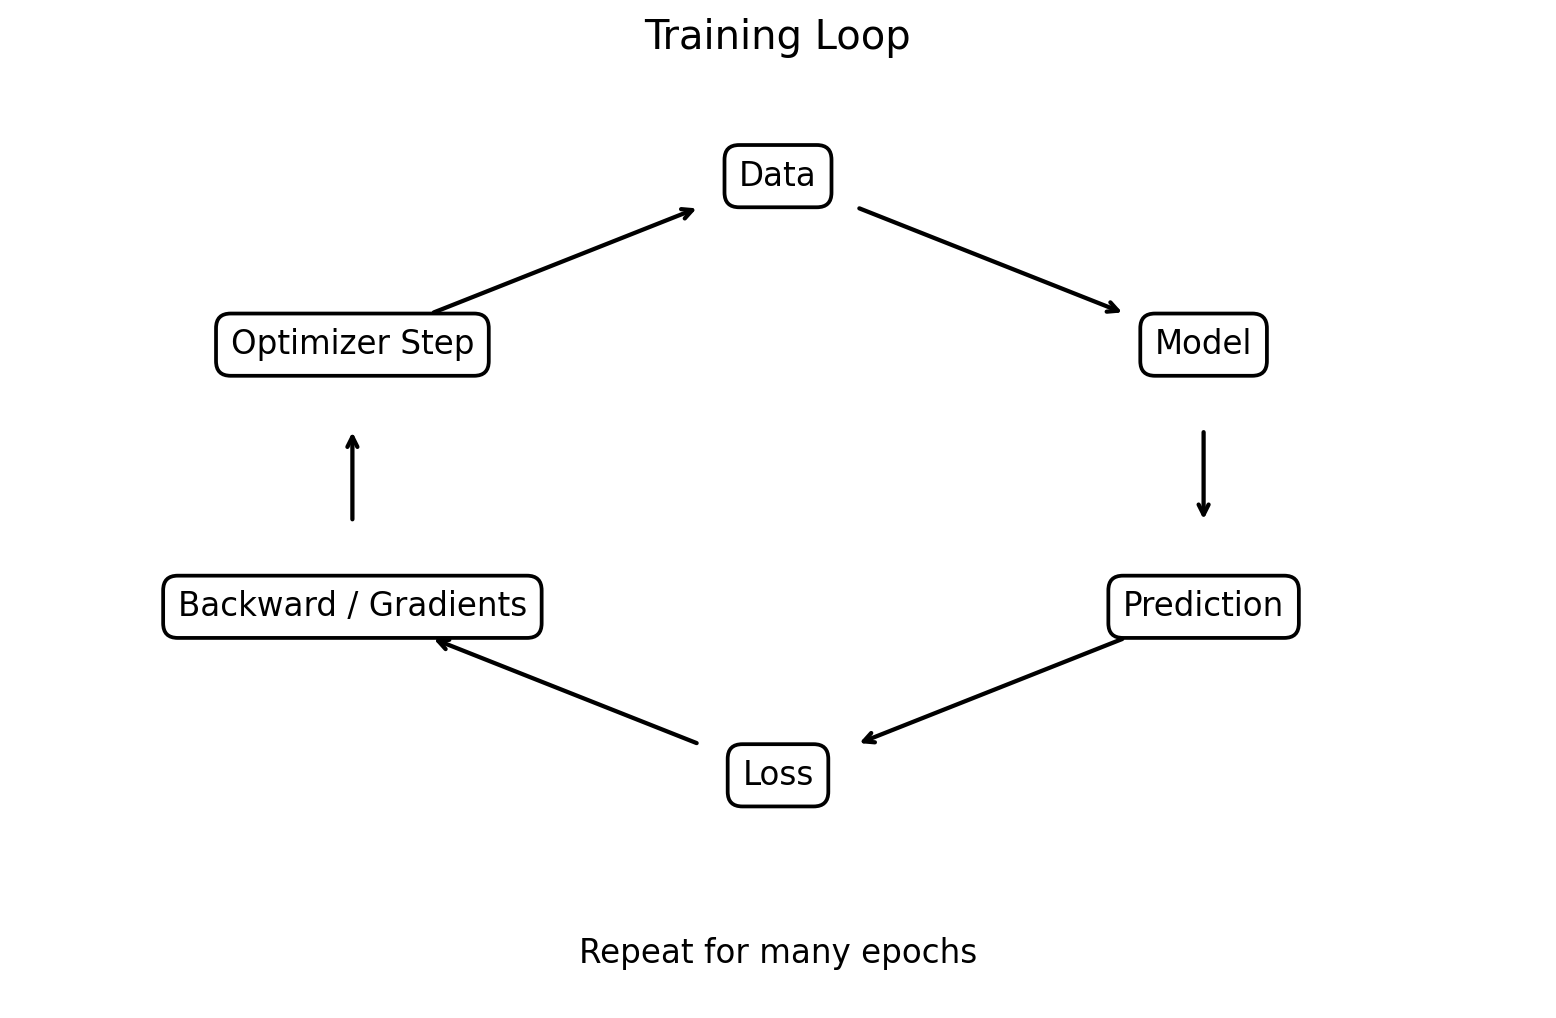

</div>

</div>

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

## 1. <span dir="ltr">Tensors</span> ו־<span dir="ltr">Shapes</span>

<span dir="ltr">Tensor</span> הוא מבנה הנתונים המרכזי ב־<span dir="ltr">PyTorch</span>.  
אפשר לחשוב עליו כמו מערך מספרים שיודע לעבוד עם חישוב גרדיאנטים ובהמשך גם עם <span dir="ltr">GPU</span>.

</div>

In [1]:
import torch

x = torch.tensor([0.0, 10.0, 20.0, 30.0])
y = torch.tensor([32.0, 50.0, 68.0, 86.0])

print(x)
print(y)
print(x.shape)
print(y.shape)

tensor([ 0., 10., 20., 30.])
tensor([32., 50., 68., 86.])
torch.Size([4])
torch.Size([4])


<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

### תרגיל 1 — יצירת <span dir="ltr">Tensor</span>

צרו <span dir="ltr">Tensor</span> של טמפרטורות בפרנהייט שמתאים ל־<span dir="ltr">x</span>.

</div>

In [2]:
x = torch.tensor([0.0, 10.0, 20.0, 30.0])

# TODO: create the matching Fahrenheit tensor
y = torch.tensor([
    32.0,
    50.0,
    68.0,
    86.0
])

print(x)
print(y)

tensor([ 0., 10., 20., 30.])
tensor([32., 50., 68., 86.])


<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

## 2. מודל לינארי ו־<span dir="ltr">Loss</span>

נשתמש במודל פשוט:

<div dir="ltr" style="text-align:left;">

```text
y_hat = w * x + b
```

</div>

הפרמטרים שהמודל צריך ללמוד הם <span dir="ltr">w</span> ו־<span dir="ltr">b</span>.

</div>

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

<div style="text-align:center;">

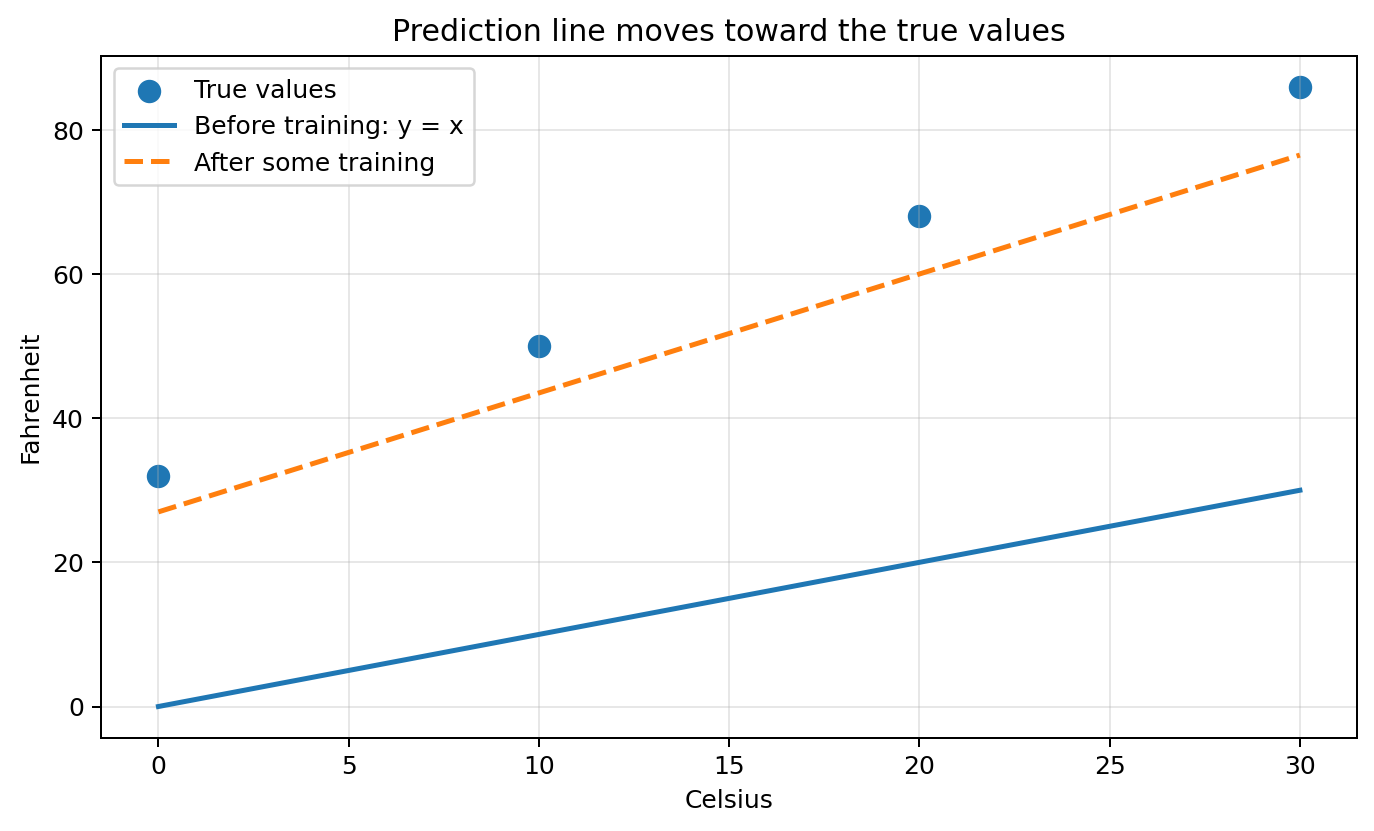

</div>

</div>

In [ ]:
import torch

x = torch.tensor([0.0, 10.0, 20.0, 30.0])
y = torch.tensor([32.0, 50.0, 68.0, 86.0])

w = torch.tensor(1.0)
b = torch.tensor(0.0)

def model(x, w, b):
    return w * x + b

def mse_loss(y_pred, y_true):
    squared_errors = (y_pred - y_true) ** 2
    return squared_errors.mean()

y_pred = model(x, w, b)
loss = mse_loss(y_pred, y)

print("Predictions:", y_pred)
print("Loss:", loss)

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

### תרגיל 2 — השלמת פונקציית <span dir="ltr">Loss</span>

</div>

In [ ]:
def mse_loss(y_pred, y_true):
    # TODO: calculate errors
    errors = y_pred - y_true

    # TODO: square the errors
    squared_errors = errors ** 2

    # TODO: return mean squared error
    return squared_errors.mean()

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

## 3. <span dir="ltr">Gradient Descent</span> ידני

המטרה היא לעדכן את הפרמטרים בכיוון שמקטין את ה־<span dir="ltr">Loss</span>.

<div dir="ltr" style="text-align:left;">

```text
parameter = parameter - learning_rate * gradient
```

</div>

הגרדיאנט אומר מה השיפוע של ה־<span dir="ltr">Loss</span> בנקודה הנוכחית.

</div>

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

<div style="text-align:center;">

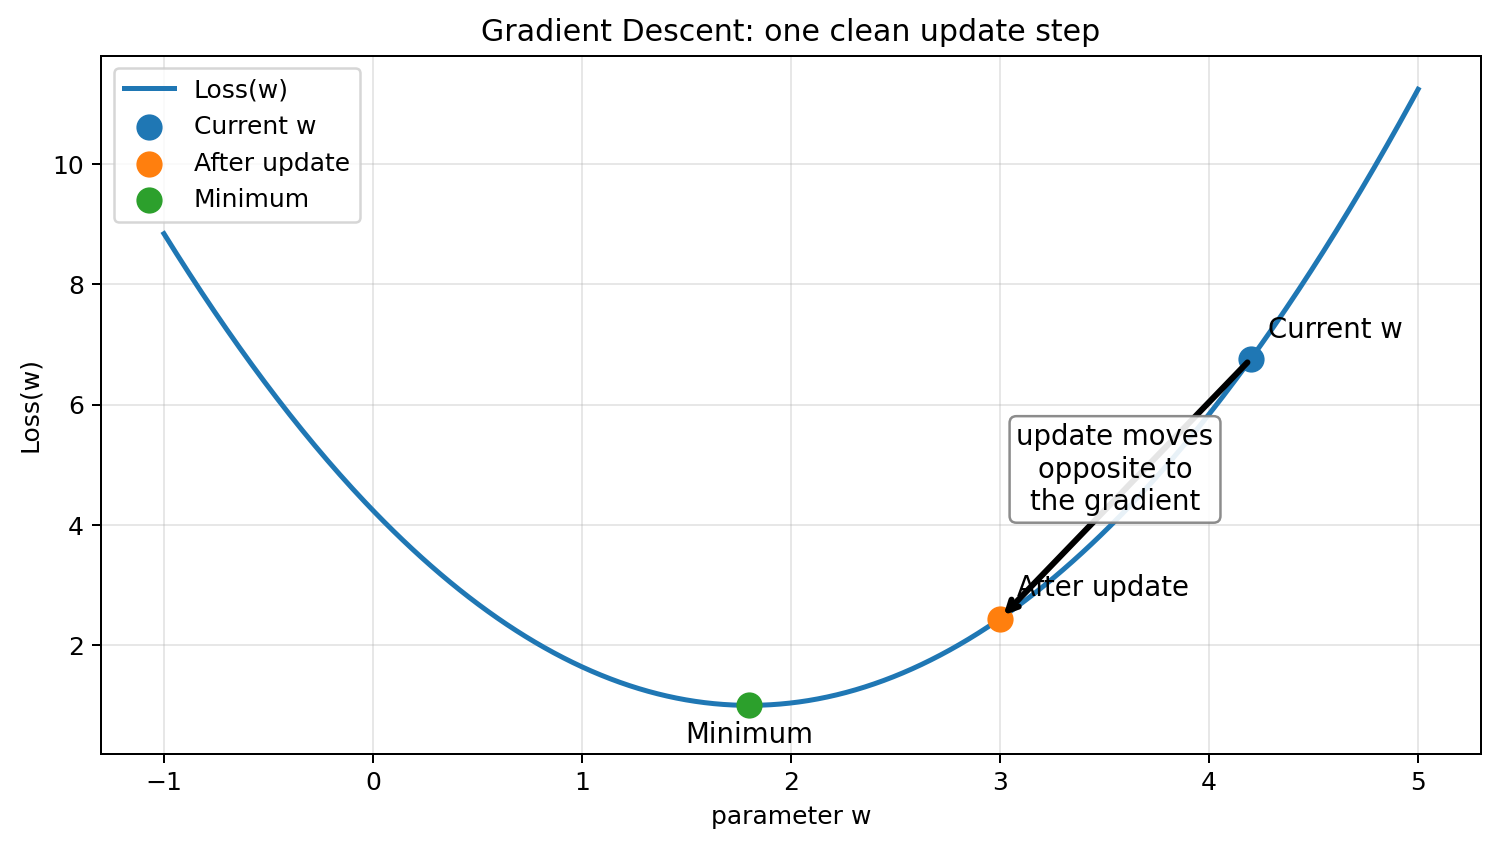

</div>

</div>

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

### השפעת <span dir="ltr">Learning Rate</span>

כל מצב מוצג בתמונה נפרדת כדי שלא יהיו עקומות שעולות אחת על השנייה.

</div>

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

<div style="text-align:center;">

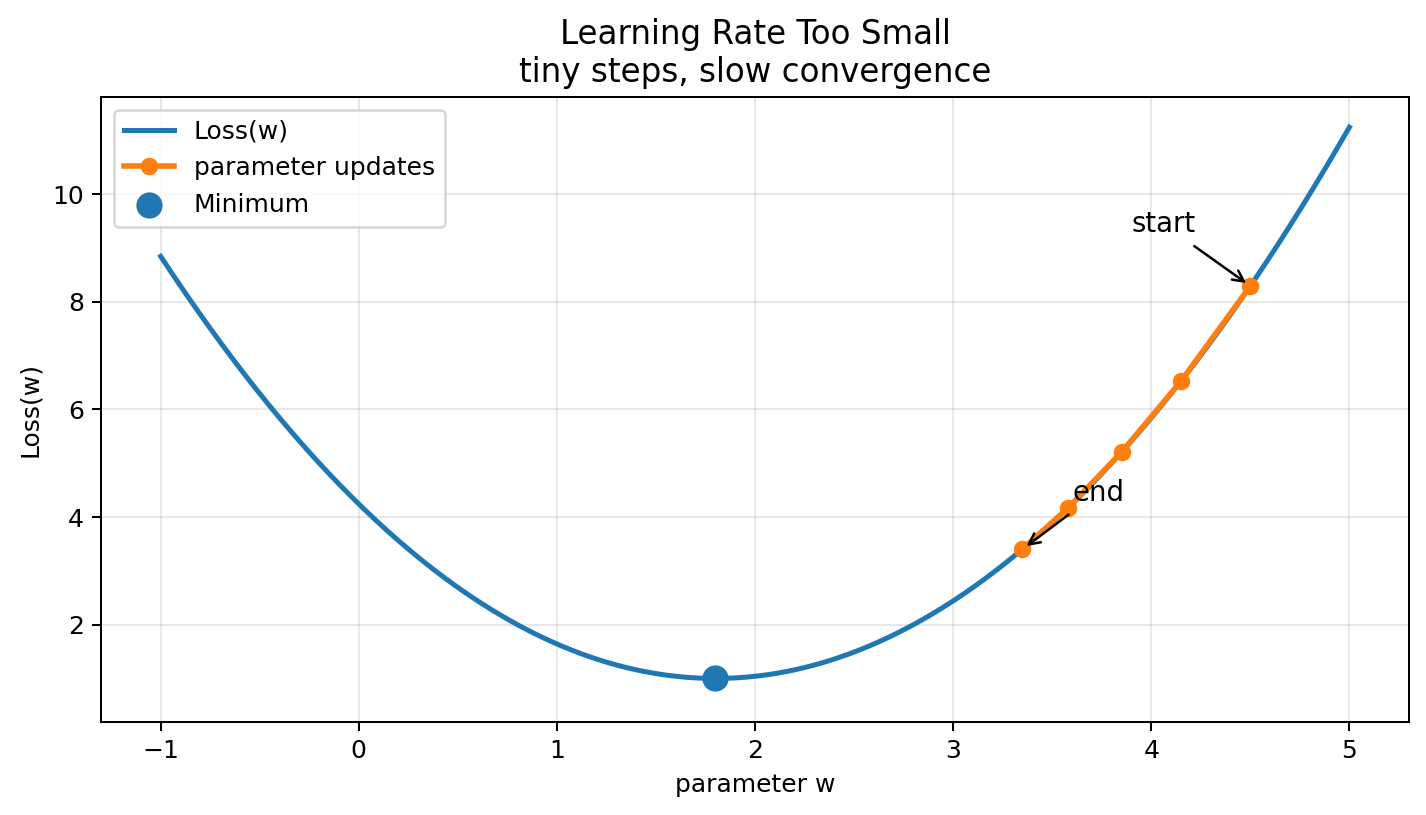

</div>

</div>

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

<div style="text-align:center;">

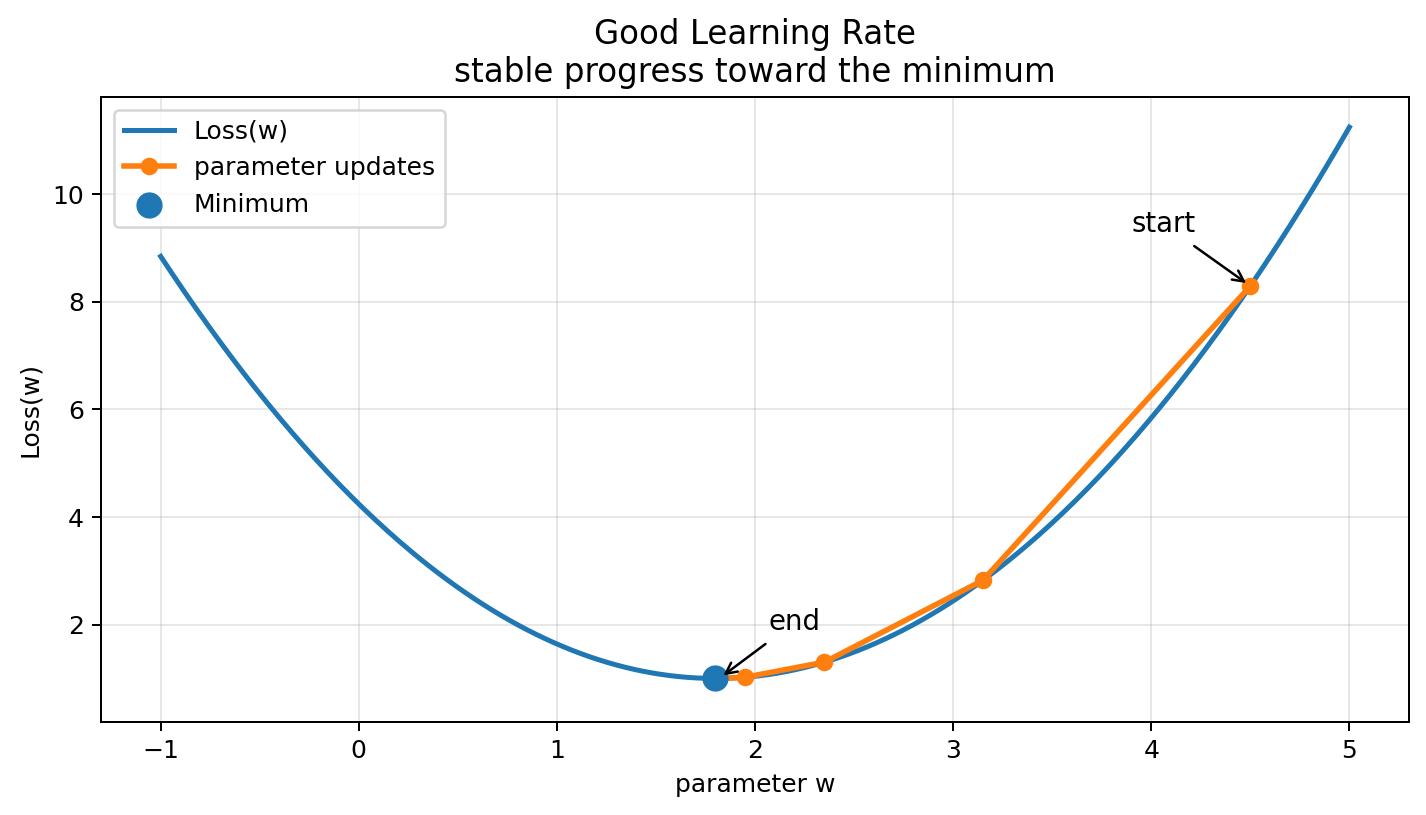

</div>

</div>

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

<div style="text-align:center;">

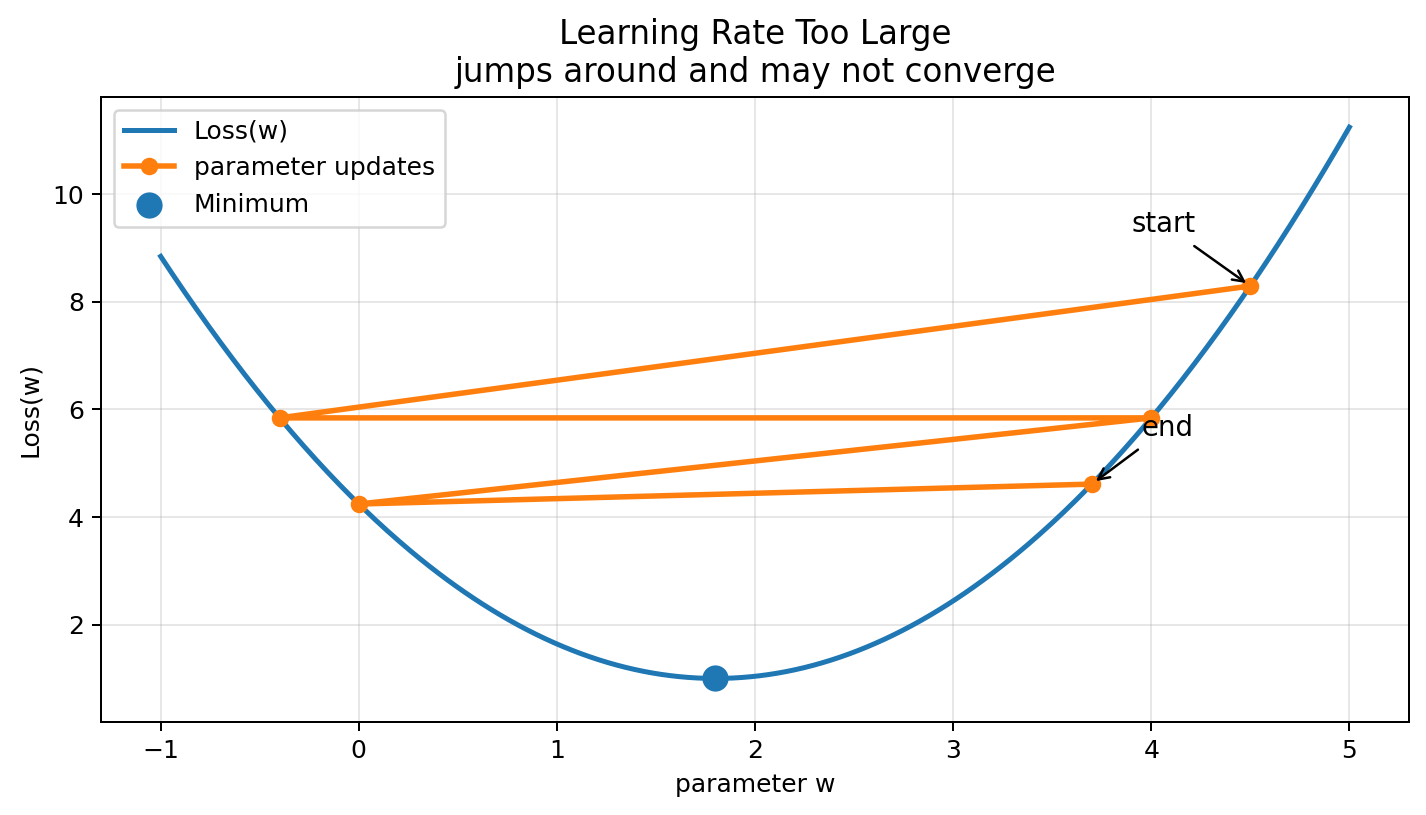

</div>

</div>

In [3]:
import torch

x = torch.tensor([0.0, 10.0, 20.0, 30.0])
y = torch.tensor([32.0, 50.0, 68.0, 86.0])

w = torch.tensor(1.0)
b = torch.tensor(0.0)

lr = 0.001

def model(x, w, b):
    return w * x + b

def mse_loss(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean()

for epoch in range(100):
    y_pred = model(x, w, b)
    loss = mse_loss(y_pred, y)

    # Manual gradients for MSE
    grad_w = (2 * (y_pred - y) * x).mean()
    grad_b = (2 * (y_pred - y)).mean()

    # Update parameters
    w = w - lr * grad_w
    b = b - lr * grad_b

    if epoch % 10 == 0:
        print(f"epoch={epoch}, loss={loss:.4f}, w={w:.4f}, b={b:.4f}")

epoch=0, loss=2016.0000, w=2.5200, b=0.0880
epoch=10, loss=358.4416, w=3.1581, b=0.3424
epoch=20, loss=353.3650, w=3.1485, b=0.5674
epoch=30, loss=348.3601, w=3.1389, b=0.7908
epoch=40, loss=343.4262, w=3.1294, b=1.0126
epoch=50, loss=338.5622, w=3.1199, b=1.2328
epoch=60, loss=333.7669, w=3.1106, b=1.4515
epoch=70, loss=329.0397, w=3.1012, b=1.6686
epoch=80, loss=324.3794, w=3.0920, b=1.8841
epoch=90, loss=319.7851, w=3.0828, b=2.0982


<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

### תרגיל 3 — השלמת עדכון הפרמטרים

</div>

In [4]:
# Update parameters
w = w - w-lr * grad_w
b = b - b-lr * grad_b

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

## 4. <span dir="ltr">Normalization</span>

נרמול משנה את הסקאלה של הנתונים כך שיהיה קל יותר לאמן את המודל.

<div dir="ltr" style="text-align:left;">

```text
x_norm = (x - mean) / std
```

</div>

</div>

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

<div style="text-align:center;">

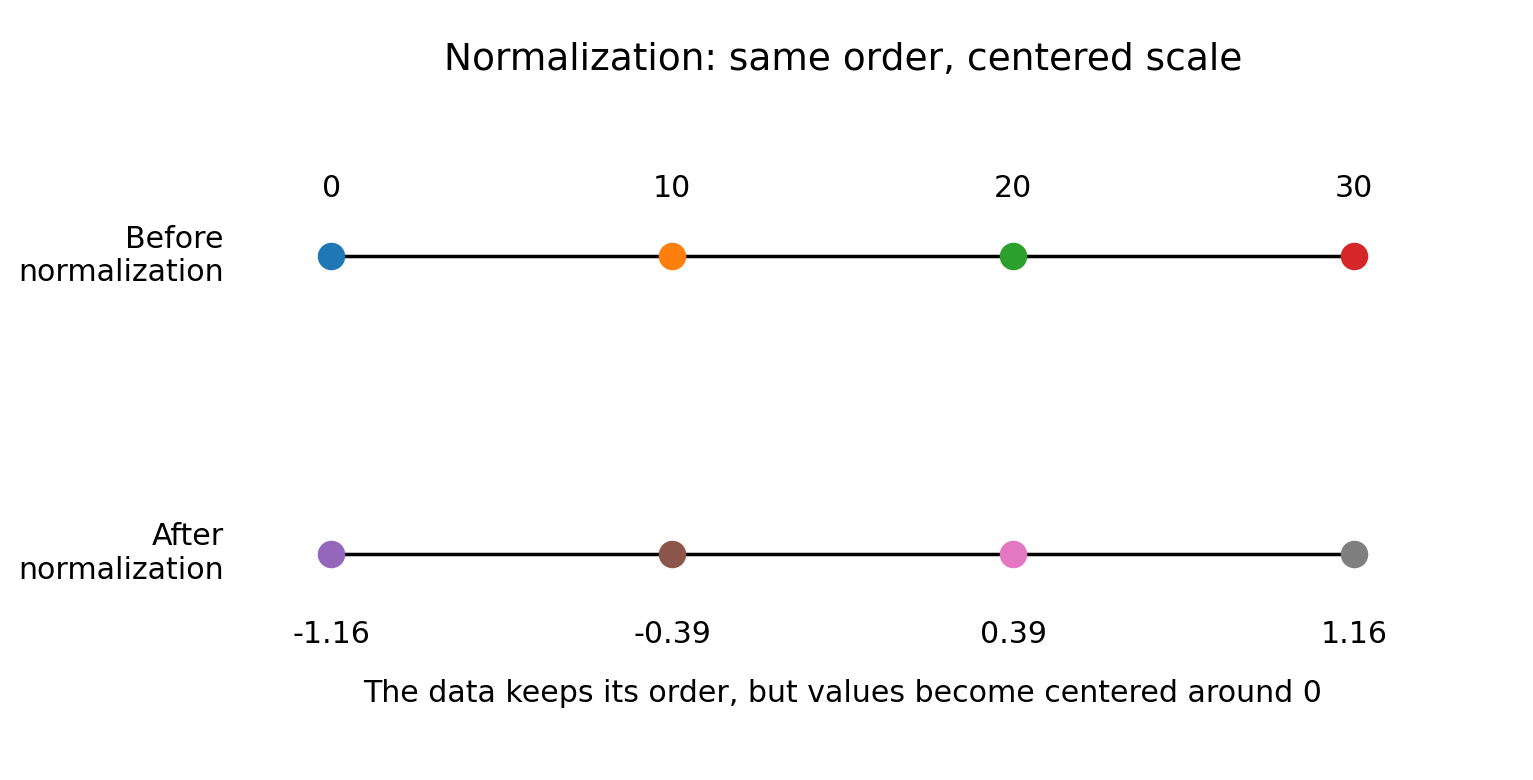

</div>

</div>

In [5]:
x = torch.tensor([0.0, 10.0, 20.0, 30.0])

x_mean = x.mean()
x_std = x.std()

x_norm = (x - x_mean) / x_std

print("Original x:", x)
print("Normalized x:", x_norm)
print("Mean:", x_norm.mean())
print("Std:", x_norm.std())

Original x: tensor([ 0., 10., 20., 30.])
Normalized x: tensor([-1.1619, -0.3873,  0.3873,  1.1619])
Mean: tensor(0.)
Std: tensor(1.)


<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

### תרגיל 4 — השלמת <span dir="ltr">Normalization</span>

</div>

In [7]:
x_mean = x.mean()
x_std = x.std()

x_norm = (x - x_mean) / x_std

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

## 5. <span dir="ltr">PyTorch Autograd</span>

במקום לחשב גרדיאנטים ידנית, <span dir="ltr">PyTorch</span> יכול לחשב אותם עבורנו.

כדי לבקש מ־<span dir="ltr">PyTorch</span> לעקוב אחרי <span dir="ltr">Tensor</span>, נשתמש ב־<span dir="ltr">requires_grad=True</span>.

אחרי חישוב ה־<span dir="ltr">Loss</span> נקרא ל־<span dir="ltr">loss.backward()</span>.

</div>

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

<div style="text-align:center;">

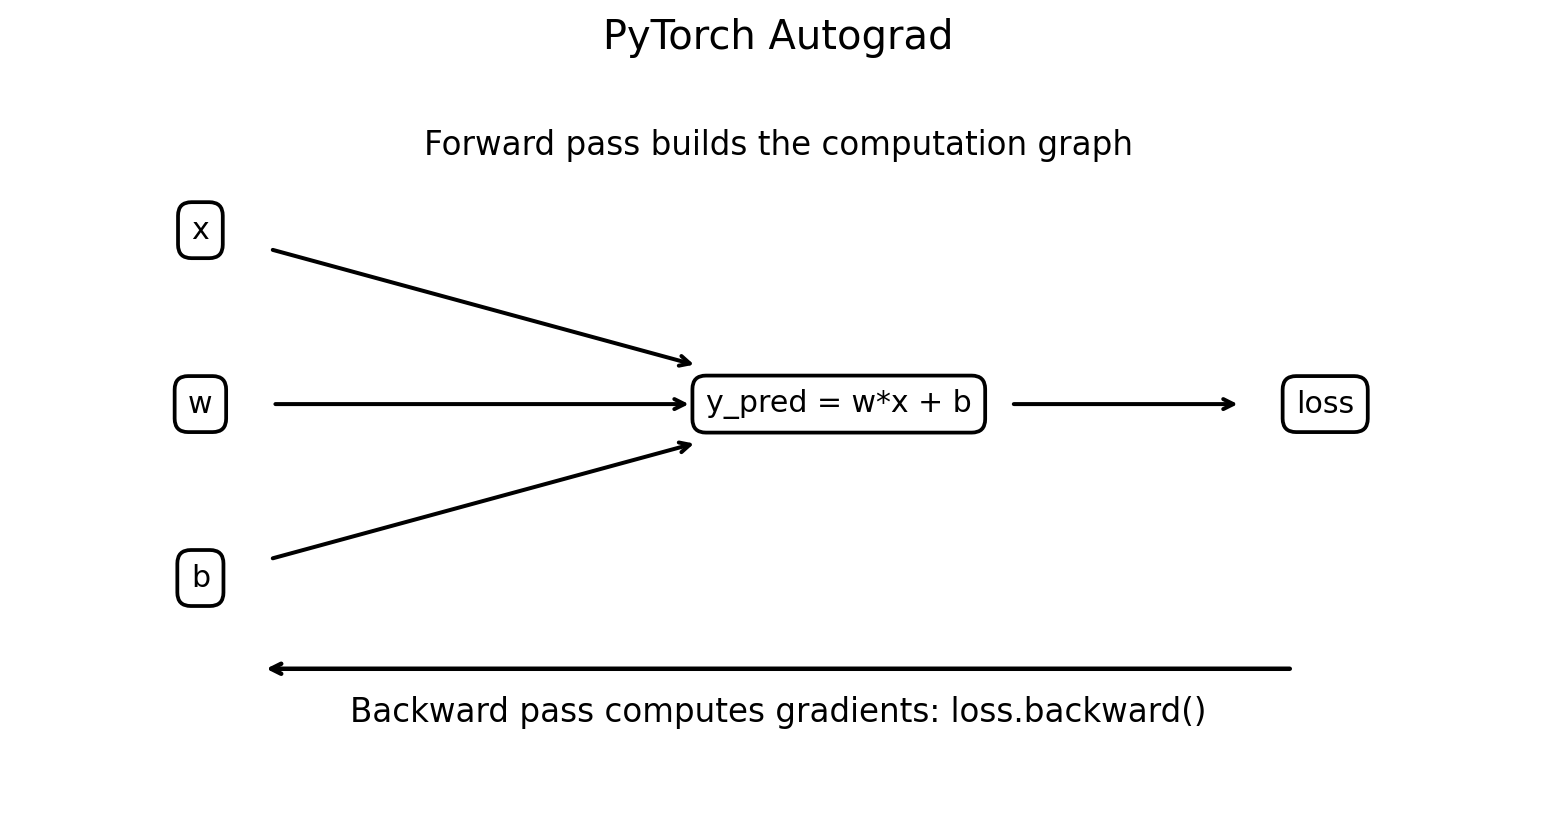

</div>

</div>

In [9]:
import torch

x = torch.tensor([0.0, 10.0, 20.0, 30.0])
y = torch.tensor([32.0, 50.0, 68.0, 86.0])

w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

def model(x, w, b):
    return w * x + b

def mse_loss(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean()

y_pred = model(x, w, b)
loss = mse_loss(y_pred, y)

loss.backward()

print("Loss:", loss.item())
print("Gradient w:", w.grad)
print("Gradient b:", b.grad)

Loss: 2016.0
Gradient w: tensor(-1520.)
Gradient b: tensor(-88.)


<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

### תרגיל 5 — השלמת <span dir="ltr">Autograd</span>

</div>

In [10]:
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

y_pred = model(x, w, b)
loss = mse_loss(y_pred, y)

# TODO: calculate gradients
loss.backward()

print(w.grad)
print(b.grad)

tensor(-1520.)
tensor(-88.)


<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

## 6. <span dir="ltr">Training Loop</span> עם <span dir="ltr">Optimizer</span>

בכל <span dir="ltr">epoch</span>: חיזוי, חישוב <span dir="ltr">Loss</span>, איפוס גרדיאנטים, <span dir="ltr">Backward</span>, ואז <span dir="ltr">Step</span>.

</div>

In [13]:
import torch

x = torch.tensor([0.0, 10.0, 20.0, 30.0])
y = torch.tensor([32.0, 50.0, 68.0, 86.0])

w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

optimizer = torch.optim.SGD([w, b], lr=0.001)

def model(x, w, b):
    return w * x + b

def mse_loss(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean()

for epoch in range(30000):
    y_pred = model(x, w, b)
    loss = mse_loss(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"epoch={epoch}, loss={loss.item():.4f}, w={w.item():.4f}, b={b.item():.4f}")

print("Final w:", w.item())
print("Final b:", b.item())

epoch=0, loss=2016.0000, w=2.5200, b=0.0880
epoch=50, loss=338.5622, w=3.1199, b=1.2328
epoch=100, loss=315.2559, w=3.0737, b=2.3107
epoch=150, loss=293.5540, w=3.0291, b=3.3508
epoch=200, loss=273.3461, w=2.9860, b=4.3544
epoch=250, loss=254.5293, w=2.9445, b=5.3230
epoch=300, loss=237.0078, w=2.9044, b=6.2575
epoch=350, loss=220.6924, w=2.8657, b=7.1594
epoch=400, loss=205.5002, w=2.8283, b=8.0296
epoch=450, loss=191.3538, w=2.7923, b=8.8694
epoch=500, loss=178.1812, w=2.7576, b=9.6797
epoch=550, loss=165.9155, w=2.7240, b=10.4617
epoch=600, loss=154.4940, w=2.6916, b=11.2162
epoch=650, loss=143.8588, w=2.6604, b=11.9443
epoch=700, loss=133.9557, w=2.6303, b=12.6469
epoch=750, loss=124.7343, w=2.6012, b=13.3249
epoch=800, loss=116.1477, w=2.5731, b=13.9792
epoch=850, loss=108.1523, w=2.5460, b=14.6105
epoch=900, loss=100.7072, w=2.5199, b=15.2197
epoch=950, loss=93.7746, w=2.4947, b=15.8076
epoch=1000, loss=87.3192, w=2.4703, b=16.3749
epoch=1050, loss=81.3083, w=2.4468, b=16.9223
ep

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

### תרגיל 6 — השלמת <span dir="ltr">Training Loop</span>

</div>

In [ ]:
for epoch in range(300):
    y_pred = model(x, w, b)
    loss = mse_loss(y_pred, y)

    # TODO: reset gradients
    optimizer.zero_grad()

    # TODO: calculate gradients
    loss.backward()

    # TODO: update parameters
    optimizer.step()

<div dir="rtl" style="text-align:right; font-family:Arial, sans-serif;" markdown="1">

## 7. משימת סיום

שנו את הנתונים כך שהמודל ילמד:

<div dir="ltr" style="text-align:left;">

```text
y = 3x + 5
```

</div>

בדקו האם בסוף האימון מתקבלים בערך: <span dir="ltr">w ≈ 3</span>, <span dir="ltr">b ≈ 5</span>.

</div>

In [15]:
x = torch.tensor([1.0, 2.0, 3.0, 4.0])
y = torch.tensor([8.0, 11.0, 14.0, 17.0])

# TODO: reuse the training loop and check the learned parameters
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(6.0, requires_grad=True)

optimizer = torch.optim.SGD([w, b], lr=0.001)
def model(x, w, b):
    return w * x + b
def mse_loss(y_pred, y):
    return ((y_pred - y) ** 2).mean()

for epoch in range(3000):
    y_pred = model(x, w, b)
    loss = mse_loss(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"epoch={epoch}, loss={loss.item():.4f}, w={w.item():.4f}, b={b.item():.4f}")

epoch=0, loss=21.0000, w=1.0250, b=6.0080
epoch=500, loss=0.2808, w=2.5588, b=6.2961
epoch=1000, loss=0.2081, w=2.6204, b=6.1160
epoch=1500, loss=0.1543, w=2.6732, b=5.9608
epoch=2000, loss=0.1144, w=2.7186, b=5.8272
epoch=2500, loss=0.0848, w=2.7578, b=5.7122
